In [175]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [176]:
aapl= pd.read_csv("stocks/AAPL.csv")
aapl.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [177]:
aapl.shape

(9909, 7)

In [178]:
aapl["aapl"]="yellow"
aapl["y"]=aapl["Date"]

In [179]:
companies=["AAPL", "MSFT", "AMZN", "NVDA", "GOOGL", "TSLA", "NFLX"]
df=[]
for i in companies:
    a = pd.read_csv(f"stocks/{i}.csv")
    a["Company_name"]= i
    df.append(a)

qqq= pd.read_csv("etfs/QQQ.csv")
qqq["Company_name"]="QQQ"
df.append(qqq)

combine =pd.concat(df, ignore_index=True)

In [180]:
print(combine["Date"].dtype)

object


In [181]:
combine["Date"]=pd.to_datetime(combine["Date"])

In [182]:
filter= combine[(combine["Date"] > "2018-01-01") & (combine["Date"] < "2020-03-31")].reset_index(drop=True)

In [183]:
filter.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Company_name    0
dtype: int64

In [184]:
def daily_return(filter):
    today=filter
    yesterday=filter.shift(1)
    d_return= (today-yesterday)/yesterday
    return d_return

filter["Daily Return"] = filter.groupby("Company_name")["Adj Close"].transform(daily_return)

#OR ("use builtin fuction")
#filter["daily_return"] = filter.groupby("Company_name")["Adj Close"].transform(lambda x: x.pct_change())
filter.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Company_name,Daily Return
0,2018-01-02,170.160004,172.300003,169.259995,172.259995,166.804016,25555900.0,AAPL,NaN
1,2018-01-03,172.529999,174.550003,171.960007,172.229996,166.774963,29517900.0,AAPL,-0.000174
2,2018-01-04,172.539993,173.470001,172.080002,173.029999,167.549622,22434600.0,AAPL,0.004645
3,2018-01-05,173.440002,175.369995,173.050003,175.000000,169.457214,23660000.0,AAPL,0.011385
4,2018-01-08,174.350006,175.610001,173.929993,174.350006,168.827820,20567800.0,AAPL,-0.003714


In [185]:
def return_zscore(group):
    rolling_mean = group.rolling(window=63, min_periods=63).mean()
    rolling_std = group.rolling(window=63, min_periods=63).std()
    return (group - rolling_mean) / rolling_std

filter["ret_z"] = filter.groupby("Company_name")["Daily Return"].transform(return_zscore)
filter.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Company_name,Daily Return,ret_z
0,2018-01-02,170.160004,172.300003,169.259995,172.259995,166.804016,25555900.0,AAPL,NaN,NaN
1,2018-01-03,172.529999,174.550003,171.960007,172.229996,166.774963,29517900.0,AAPL,-0.000174,NaN
2,2018-01-04,172.539993,173.470001,172.080002,173.029999,167.549622,22434600.0,AAPL,0.004645,NaN
3,2018-01-05,173.440002,175.369995,173.050003,175.000000,169.457214,23660000.0,AAPL,0.011385,NaN
4,2018-01-08,174.350006,175.610001,173.929993,174.350006,168.827820,20567800.0,AAPL,-0.003714,NaN


In [186]:
def volume_zscore(vol):
    rolling_mean= np.log(vol).rolling(window=21, min_periods=21).mean()
    rolling_std = np.log(vol).rolling(window=21, min_periods=21).std()
    return (np.log(vol) - rolling_mean)/rolling_std

filter["vol_z"]= filter.groupby("Company_name")["Volume"].transform(volume_zscore)
filter.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Company_name,Daily Return,ret_z,vol_z
0,2018-01-02,170.160004,172.300003,169.259995,172.259995,166.804016,25555900.0,AAPL,NaN,NaN,NaN
1,2018-01-03,172.529999,174.550003,171.960007,172.229996,166.774963,29517900.0,AAPL,-0.000174,NaN,NaN
2,2018-01-04,172.539993,173.470001,172.080002,173.029999,167.549622,22434600.0,AAPL,0.004645,NaN,NaN
3,2018-01-05,173.440002,175.369995,173.050003,175.000000,169.457214,23660000.0,AAPL,0.011385,NaN,NaN
4,2018-01-08,174.350006,175.610001,173.929993,174.350006,168.827820,20567800.0,AAPL,-0.003714,NaN,NaN


In [187]:
from scipy.stats import percentileofscore

def range_percentile(group):
    daily_range = (group["High"] - group["Low"]) / group["Close"]
    
    def get_percentile(window):
        return percentileofscore(window, window.iloc[-1])
    
    return daily_range.rolling(window=63, min_periods=63).apply(get_percentile)

filter["range_pct"] = filter.groupby("Company_name", group_keys=False).apply(range_percentile)
filter.head()

C:\Users\Shagy\AppData\Local\Temp\ipykernel_9012\2457763650.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filter["range_pct"] = filter.groupby("Company_name", group_keys=False).apply(range_percentile)


,Date,Open,High,Low,Close,Adj Close,Volume,Company_name,Daily Return,ret_z,vol_z,range_pct
0,2018-01-02,170.160004,172.300003,169.259995,172.259995,166.804016,25555900.0,AAPL,NaN,NaN,NaN,NaN
1,2018-01-03,172.529999,174.550003,171.960007,172.229996,166.774963,29517900.0,AAPL,-0.000174,NaN,NaN,NaN
2,2018-01-04,172.539993,173.470001,172.080002,173.029999,167.549622,22434600.0,AAPL,0.004645,NaN,NaN,NaN
3,2018-01-05,173.440002,175.369995,173.050003,175.000000,169.457214,23660000.0,AAPL,0.011385,NaN,NaN,NaN
4,2018-01-08,174.350006,175.610001,173.929993,174.350006,168.827820,20567800.0,AAPL,-0.003714,NaN,NaN,NaN


In [226]:
def anomaly(values):
    if np.absolute(values["ret_z"])>2.5 or values["vol_z"]>2.5 or values["range_pct"]>95 :
        return 1
    else:
        return 0
    
filter["Anomaly Flag"]= filter.apply(anomaly, axis=1)


filter.groupby(["Company_name","Anomaly Flag"])["Anomaly Flag"].value_counts()

Company_name  Anomaly Flag
AAPL          0               510
              1                54
AMZN          0               507
              1                57
GOOGL         0               502
              1                62
MSFT          0               508
              1                56
NFLX          0               514
              1                50
NVDA          0               503
              1                61
QQQ           0               508
              1                56
TSLA          0               516
              1                48
Name: count, dtype: int64

In [227]:
def stats(val):
    label = []
    
    # Check crash or spike
    if np.absolute(val["ret_z"]) > 3.0:
        if val["Daily Return"] < 0:
            label.append("Crash")
        else:
            label.append("Spike")
    
    # Check volume shock
    if val["vol_z"] > 3.0:
        label.append("Volume Shock")
    
    # Check range shock
    if val["range_pct"] > 97:
        label.append("Range Shock")
    
    # If nothing fired return Normal Day
    if len(label) == 0:
        return "Normal Day"
    
    return " + ".join(label)

filter["Stats"] = filter.apply(stats, axis=1)
filter.groupby("Company_name")["Stats"].value_counts()

Company_name  Stats               
AAPL          Normal Day              528
              Range Shock              18
              Crash                     7
              Crash + Range Shock       4
              Spike + Range Shock       2
                                     ... 
TSLA          Spike + Range Shock       2
              Volume Shock              2
              Crash + Range Shock       1
              Crash + Volume Shock      1
              Spike + Volume Shock      1
Name: count, Length: 62, dtype: int64

In [228]:
total = len(filter)
anomalous = len(filter[filter["Stats"] != "Normal Day"])
percentage = (anomalous / total) * 100
print(f"Total days : {total}")
print(f"Anomalous days : {anomalous}")
print(f"Flag rate : {percentage:.2f}%")

Total days : 4512
Anomalous days : 252
Flag rate : 5.59%


In [229]:
market_df= filter.groupby("Date")["Daily Return"].mean().reset_index()
market_df.columns= ["Date", "Market_ret"]
market_df

,Date,Market_ret
0,2018-01-02,NaN
1,2018-01-03,0.014926
2,2018-01-04,0.002921
3,2018-01-05,0.012395
4,2018-01-08,0.015280
...,...,...
559,2020-03-24,0.085803
560,2020-03-25,-0.007978
561,2020-03-26,0.043415
562,2020-03-27,-0.031287


In [230]:
filter

,Date,Open,High,Low,Close,Adj Close,Volume,Company_name,Daily Return,ret_z,vol_z,range_pct,Anomaly Flag,Stats
0,2018-01-02,170.160004,172.300003,169.259995,172.259995,166.804016,25555900.0,AAPL,NaN,NaN,NaN,NaN,0,Normal Day
1,2018-01-03,172.529999,174.550003,171.960007,172.229996,166.774963,29517900.0,AAPL,-0.000174,NaN,NaN,NaN,0,Normal Day
2,2018-01-04,172.539993,173.470001,172.080002,173.029999,167.549622,22434600.0,AAPL,0.004645,NaN,NaN,NaN,0,Normal Day
3,2018-01-05,173.440002,175.369995,173.050003,175.000000,169.457214,23660000.0,AAPL,0.011385,NaN,NaN,NaN,0,Normal Day
4,2018-01-08,174.350006,175.610001,173.929993,174.350006,168.827820,20567800.0,AAPL,-0.003714,NaN,NaN,NaN,0,Normal Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4507,2020-03-24,179.910004,183.830002,177.949997,183.660004,183.660004,94881800.0,QQQ,0.077438,2.375260,-0.621701,74.603175,0,Normal Day
4508,2020-03-25,184.419998,189.509995,179.979996,182.300003,182.300003,88754900.0,QQQ,-0.007405,-0.168611,-0.915551,84.126984,0,Normal Day
4509,2020-03-26,183.869995,192.720001,183.610001,191.899994,191.899994,79887600.0,QQQ,0.052660,1.577593,-1.433685,79.365079,0,Normal Day
4510,2020-03-27,186.929993,190.509995,184.660004,185.300003,185.300003,58845000.0,QQQ,-0.034393,-0.956675,-2.351476,68.253968,0,Normal Day


In [235]:
def breadth (values):
    positive_return= (values["Daily Return"]>0).sum()
    no_stocks= filter["Company_name"].nunique()
    return positive_return/no_stocks
    
market_df["Breadth"]= filter.groupby("Date",group_keys=False).apply(breadth).values
market_df.head()

C:\Users\Shagy\AppData\Local\Temp\ipykernel_9012\1226566773.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  market_df["Breadth"]= filter.groupby("Date",group_keys=False).apply(breadth).values


,Date,Market_ret,Breadth
0,2018-01-02,NaN,0.000
1,2018-01-03,0.014926,0.750
2,2018-01-04,0.002921,0.875
3,2018-01-05,0.012395,1.000
4,2018-01-08,0.015280,0.875


In [262]:
market_df["rolling"]=market_df["Market_ret"].abs().rolling(window=63, min_periods=63).apply(lambda x: np.percentile(x, 95))

def market_anamoly(values):
    if np.abs(values["Market_ret"])>values["rolling"] :
        return 1
    else:
        return 0

market_df["market_anomaly_flag"]= market_df.apply(market_anamoly, axis=1)
market_df["market_anomaly_flag"].value_counts()

market_anomaly_flag
0    524
1     40
Name: count, dtype: int64

In [261]:
market_df[market_df["Breadth"]<0.05].shape

(77, 5)

In [263]:
market_df[market_df["market_anomaly_flag"]==1].tail(20)

,Date,Market_ret,Breadth,rolling,market_anomaly_flag
406,2019-08-14,-0.037061,0.000,0.029125,1
413,2019-08-23,-0.036458,0.000,0.035763,1
421,2019-09-05,0.026795,1.000,0.026688,1
456,2019-10-24,0.028675,1.000,0.028487,1
503,2020-01-02,0.021805,1.000,0.018056,1
510,2020-01-13,0.027004,1.000,0.021238,1
519,2020-01-27,-0.023794,0.000,0.021188,1
520,2020-01-28,0.019336,1.000,0.019164,1
524,2020-02-03,0.040265,0.750,0.021559,1
525,2020-02-04,0.035341,0.875,0.023595,1


In [264]:
stock_df = filter

In [266]:
stock_df.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Company_name', 'Daily Return', 'ret_z', 'vol_z', 'range_pct',
       'Anomaly Flag', 'Stats'],
      dtype='object')

In [267]:
market_df.columns

Index(['Date', 'Market_ret', 'Breadth', 'rolling', 'market_anomaly_flag'], dtype='object')

In [270]:
stock_df.to_csv("outputs/anomaly_cards.csv", index=False)
market_df.to_csv("outputs/market_days.csv", index=False)

In [324]:
train= stock_df[(stock_df["Date"] >= "2018-01-01") & (stock_df["Date"]<= "2018-12-31")]
val= stock_df[(stock_df["Date"] >= "2019-01-01") & (stock_df["Date"]<= "2019-12-31")]
test= stock_df[(stock_df["Date"] >= "2020-01-01") & (stock_df["Date"]<= "2020-12-31")]


In [333]:
print(train.shape)
print(val.shape)
print(test.shape)

(2008, 14)
(2016, 14)
(488, 14)


In [334]:
train.isnull().sum()

Date              0
Open              0
High              0
Low               0
Close             0
Adj Close         0
Volume            0
Company_name      0
Daily Return      8
ret_z           504
vol_z           160
range_pct       496
Anomaly Flag      0
Stats             0
dtype: int64

In [335]:
train = train.dropna(subset=["ret_z", "vol_z", "range_pct"])
val = val.dropna(subset=["ret_z", "vol_z", "range_pct"])
test = test.dropna(subset=["ret_z", "vol_z", "range_pct"])

In [336]:
train.isnull().sum()

Date            0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
Company_name    0
Daily Return    0
ret_z           0
vol_z           0
range_pct       0
Anomaly Flag    0
Stats           0
dtype: int64

In [337]:
print(train.shape)
print(val.shape)
print(test.shape)

(1504, 14)
(2016, 14)
(488, 14)


In [338]:
# scaling feature
import sklearn
from sklearn.preprocessing import StandardScaler
std= StandardScaler()
feature=["ret_z","vol_z","range_pct"]
train_scaled=std.fit_transform(train[feature])
test_scaled= std.transform(test[feature])
val_scaled=std.transform(val[feature])

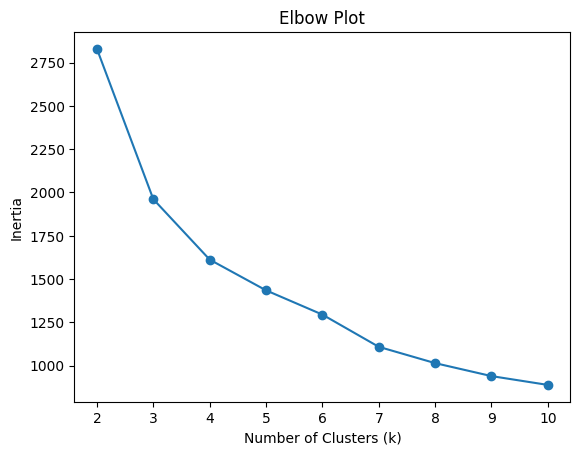

In [339]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(train_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(k_values, inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot")
plt.show()

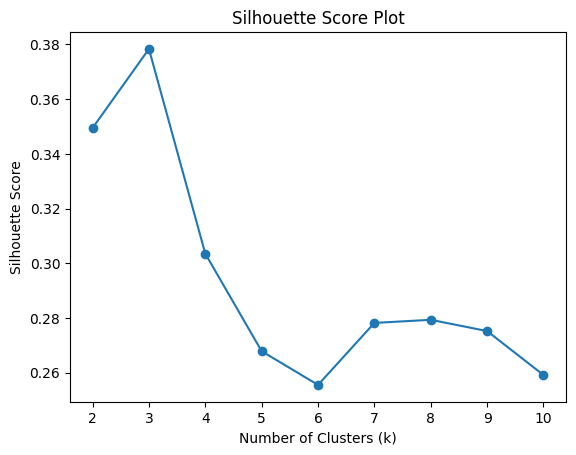

In [340]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(train_scaled)
    score = silhouette_score(train_scaled, labels)
    silhouette_scores.append(score)

plt.plot(k_values, silhouette_scores, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score Plot")
plt.show()

In [341]:
kmeans= KMeans(n_clusters=3, random_state=42)
distances=kmeans.fit_transform(train_scaled)
min_distances = distances.min(axis=1)

In [342]:
print(min_distances)

[0.76399446 0.43559839 0.67838285 ... 0.96738615 1.02484659 0.63786578]


In [364]:
train_labels=kmeans.fit_predict(train_scaled)

In [365]:
thresholds={}
for cluster in range(3):
    cluster_distance=min_distances[train_labels==cluster]
    thresholds[cluster]=np.percentile(cluster_distance, 97.5)

print(thresholds)

{0: np.float64(1.7859981458633452), 1: np.float64(2.6356910553610278), 2: np.float64(2.5062687449760195)}


In [377]:
data=[]
for i in range(len(min_distances)):
    if thresholds[train_labels[i]]< min_distances[i]:
        data.append(1)
    else:
        data.append(0)


train["Kmeans Anomaly Flag"]= data

In [378]:
train["Kmeans Anomaly Flag"].value_counts()

Kmeans Anomaly Flag
0    1465
1      39
Name: count, dtype: int64

In [382]:
val_distances= kmeans.transform(val_scaled)
val_min_distances=val_distances.min(axis=1)
val_labels= kmeans.predict(val_scaled)

val_data=[]
for i in range(len(val_min_distances)):
    if val_min_distances[i] > thresholds[val_labels[i]]:
        val_data.append(1)
    else:
        val_data.append(0)
val["Kmeans Anomaly Flag"]=val_data


test_distances=kmeans.transform(test_scaled)
test_min_distances=test_distances.min(axis=1)
test_labels= kmeans.predict(test_scaled)

test_data=[]
for i in range(len(test_min_distances)):
    if test_min_distances[i] > thresholds[test_labels[i]]:
        test_data.append(1)
    else:
        test_data.append(0)
test["Kmeans Anomaly Flag"]=test_data

In [384]:
val["Kmeans Anomaly Flag"].value_counts()

Kmeans Anomaly Flag
0    1971
1      45
Name: count, dtype: int64

In [385]:
test["Kmeans Anomaly Flag"].value_counts()

Kmeans Anomaly Flag
0    464
1     24
Name: count, dtype: int64

In [391]:
test[test["Kmeans Anomaly Flag"]==1][["Date","Company_name","ret_z","vol_z","range_pct"]].size

120

In [392]:
test[test["Kmeans Anomaly Flag"]==1]["Date"].unique()

<DatetimeArray>
['2020-02-27 00:00:00', '2020-03-02 00:00:00', '2020-03-13 00:00:00',
 '2020-01-30 00:00:00', '2020-01-31 00:00:00', '2020-02-14 00:00:00',
 '2020-03-16 00:00:00', '2020-02-03 00:00:00', '2020-02-04 00:00:00',
 '2020-02-05 00:00:00', '2020-01-23 00:00:00', '2020-02-20 00:00:00',
 '2020-01-27 00:00:00', '2020-02-24 00:00:00', '2020-03-25 00:00:00',
 '2020-03-27 00:00:00', '2020-03-30 00:00:00']
Length: 17, dtype: datetime64[ns]

from sklearn.metrics.pairwise import euclidean_distances

distances_matrix = euclidean_distances(train_scaled)
k_distances = []

for i in range(len(train_scaled)):
    distances_to_others = sorted(distances_matrix[i])
    k_distances.append(distances_to_others[10])

k_distances = sorted(k_distances)

plt.plot(k_distances)
plt.xlabel("Points")
plt.ylabel("10th Nearest Neighbor Distance")
plt.title("K Distance Graph")
plt.show()

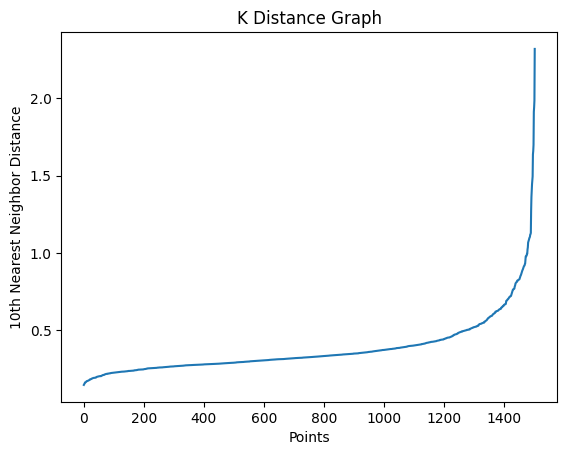

In [395]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=10)
neighbors.fit(train_scaled)
distances, indices = neighbors.kneighbors(train_scaled)

k_distances = sorted(distances[:, 9])

plt.plot(k_distances)
plt.xlabel("Points")
plt.ylabel("10th Nearest Neighbor Distance")
plt.title("K Distance Graph")
plt.show()

In [397]:
print(k_distances[1200])
print(k_distances[1300])
print(k_distances[1400])

0.4441281530473334
0.5208430471802417
0.6642623043924247


In [399]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=10)
train_dbscan_labels = dbscan.fit_predict(train_scaled)

print(pd.Series(train_dbscan_labels).value_counts())

 0    1438
-1      66
Name: count, dtype: int64


In [400]:
train["DBSCAN_flag"] = (train_dbscan_labels == -1).astype(int)

In [403]:
train["DBSCAN_flag"].value_counts()

DBSCAN_flag
0    1438
1      66
Name: count, dtype: int64

In [404]:
# Val - combine train + val
train_val_scaled = np.vstack([train_scaled, val_scaled])
train_val_labels = dbscan.fit_predict(train_val_scaled)

# Take only val portion (last 2016 rows)
val_dbscan_labels = train_val_labels[len(train_scaled):]
val["DBSCAN_flag"] = (val_dbscan_labels == -1).astype(int)
print(val["DBSCAN_flag"].value_counts())

# Test - combine train + val + test
train_val_test_scaled = np.vstack([train_scaled, val_scaled, test_scaled])
train_val_test_labels = dbscan.fit_predict(train_val_test_scaled)

# Take only test portion (last 488 rows)
test_dbscan_labels = train_val_test_labels[len(train_scaled) + len(val_scaled):]
test["DBSCAN_flag"] = (test_dbscan_labels == -1).astype(int)
print(test["DBSCAN_flag"].value_counts())

DBSCAN_flag
0    1977
1      39
Name: count, dtype: int64
DBSCAN_flag
0    479
1      9
Name: count, dtype: int64


In [406]:
test[test["DBSCAN_flag"]==1]["Date"]

1116   2020-03-13
1651   2020-01-31
2244   2020-03-13
2245   2020-03-16
2775   2020-01-27
3344   2020-02-03
3901   2020-01-23
4510   2020-03-27
4511   2020-03-30
Name: Date, dtype: datetime64[ns]

In [414]:
train["Union Column"]= ((train["Kmeans Anomaly Flag"]==1) | (train["DBSCAN_flag"]==1)).astype(int)
val["Union Column"]= ((val["Kmeans Anomaly Flag"]==1) | (val["DBSCAN_flag"]==1)).astype(int)
test["Union Column"]= ((test["Kmeans Anomaly Flag"]==1) | (test["DBSCAN_flag"]==1)).astype(int)

In [415]:
train["Intersection Column"]= ((train["Kmeans Anomaly Flag"]==1) & (train["DBSCAN_flag"]==1)).astype(int)
val["Intersection Column"]= ((val["Kmeans Anomaly Flag"]==1) & (val["DBSCAN_flag"]==1)).astype(int)
test["Intersection Column"]= ((test["Kmeans Anomaly Flag"]==1) & (test["DBSCAN_flag"]==1)).astype(int)

In [416]:
print(test["Union Column"].value_counts())
print(test["Intersection Column"].value_counts())

Union Column
0    462
1     26
Name: count, dtype: int64
Intersection Column
0    481
1      7
Name: count, dtype: int64


In [417]:
test[test["Intersection Column"]==1]["Date"].unique()

<DatetimeArray>
['2020-03-13 00:00:00', '2020-01-31 00:00:00', '2020-03-16 00:00:00',
 '2020-02-03 00:00:00', '2020-01-23 00:00:00', '2020-03-27 00:00:00',
 '2020-03-30 00:00:00']
Length: 7, dtype: datetime64[ns]

In [449]:
Query_date = pd.to_datetime(input("Enter date YYYY-MM-DD : "))

if Query_date in market_df["Date"].values:
    print(f"Market Return : {market_df[market_df['Date']==Query_date]['Market_ret'].values[0]}")
    print(f"Breadth : {market_df[market_df['Date']==Query_date]['Breadth'].values[0]}")
    print(f"Market Anomaly : {market_df[market_df['Date']==Query_date]['market_anomaly_flag'].map({0:'No', 1:'Yes'}).values[0]}")
    
    print("\nAnomalous Stocks :")
    anomalous = stock_df[(stock_df["Date"]==Query_date) & (stock_df["Anomaly Flag"]==1)]
    print(anomalous[["Company_name", "ret_z", "vol_z", "range_pct", "Stats"]].to_string(index=False))
else:
    print("No data for that date or wrong format!")

Enter date YYYY-MM-DD :  2020-03-16


Market Return : -0.1309439499994962
Breadth : 0.0
Market Anomaly : Yes

Anomalous Stocks :
Company_name     ret_z     vol_z  range_pct               Stats
        AAPL -3.439188  0.753153  93.650794               Crash
        MSFT -3.870070  0.967108  96.825397               Crash
        AMZN -2.068660  1.032527 100.000000         Range Shock
        NVDA -4.097326 -0.004262 100.000000 Crash + Range Shock
       GOOGL -3.778712  1.489482  98.412698 Crash + Range Shock
        TSLA -2.970229  0.652407  90.476190          Normal Day
        NFLX -3.498827  1.138229 100.000000 Crash + Range Shock
         QQQ -3.955760  0.278006 100.000000 Crash + Range Shock


In [455]:
Monthly_report = input("Enter month YYYY-MM : ")

report = stock_df[
    (stock_df["Date"].dt.to_period("M") == Monthly_report) & 
    (stock_df["Anomaly Flag"] == 1)
]

if len(report) == 0:
    print("No data found for that month or wrong format!")
else:
    report = report.merge(market_df[["Date", "market_anomaly_flag"]], on="Date", how="left")
    print(report[["Date", "Company_name", "ret_z", "vol_z", "range_pct", "Stats", "market_anomaly_flag"]].to_string(index=False))

Enter month YYYY-MM :  2020-03


      Date Company_name     ret_z     vol_z  range_pct               Stats  market_anomaly_flag
2020-03-02         AAPL  4.222815  1.721823  98.412698 Spike + Range Shock                    1
2020-03-03         AAPL -1.514528  1.459930  96.825397          Normal Day                    0
2020-03-09         AAPL -3.169151  1.011757  93.650794               Crash                    1
2020-03-10         AAPL  2.666204  0.911846  95.238095          Normal Day                    1
2020-03-12         AAPL -3.304713  1.447112 100.000000 Crash + Range Shock                    1
2020-03-13         AAPL  3.567626  1.100398 100.000000 Spike + Range Shock                    1
2020-03-16         AAPL -3.439188  0.753153  93.650794               Crash                    1
2020-03-20         AAPL -1.593559  1.251313 100.000000         Range Shock                    0
2020-03-24         AAPL  2.501725 -0.094767  80.952381          Normal Day                    1
2020-03-02         MSFT  3.462635  1.199

In [460]:
final_df = pd.concat([train, val, test], ignore_index=True)

In [463]:
final_df.to_csv("Outputs/anomaly_cards.csv", index=False)
market_df.to_csv("Outputs/market_days.csv", index=False)